# Yue Shi - Final Project
## ys4045

## Research Overview
This project examines trends in early ski season snow cover and snowmaking potential across the U.S. from 2000 to 2023, with ERA5 climate data extended to 2025. Results are further analyzed across four major mountain ranges (the Cascades, Sierra Nevada, Rockies, and Appalachians) to assess where winter recreation conditions might be impacted by climate change.

## Research Questions
1. How have early ski season snow cover extent and snow season length changed across major the U.S. between 2000 and 2023?
3. Have potential snowmaking hours decreased in the early ski season window?
2. Do lower-elevation areas show faster rates of snow cover decline than higher-elevation areas?
   
## Data Sources

**MODIS MOD10CM v61** — Monthly snow cover, 0.05° resolution  
Downloaded from NSIDC: https://nsidc.org/data/data-access-tool/MOD10CM/versions/61  
Time range: 2000–2023, Bounding box: 24–50°N, 66–125°W

**ERA5 Hourly Reanalysis** — 2m temperature and 2m dewpoint temperature, 0.25° resolution  
Downloaded from Copernicus CDS: https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels  
Time range: November–December, 2000–2025, Domain: 24–50°N, 66–125°W

**Copernicus DEM GLO-30** — Digital elevation model, 30m resolution  
Downloaded from AWS Open Data Registry: https://registry.opendata.aws/copernicus-dem/

### Research Part 1 Early-season snow cover extent and snow season length

Snow Season Length is defined as the number of months per year in which the snow cover fraction exceeds 50%. Linear trends are estimated via ordinary least squares regression applied independently to each grid cell, with statistical significance assessed at p < 0.10.

In [1]:
import os
os.environ['PROJ_DATA'] = '/opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj'
os.environ['PROJ_LIB']  = '/opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj'
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import netCDF4 as nc
import glob
import warnings
from scipy import stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
warnings.filterwarnings('ignore')

In [2]:
### Extract CONUS subset from global MODIS snow cover dataset
data_dir = os.path.expanduser('~/Final Project Computing/data/MODIS')
hdf_files = sorted(glob.glob(os.path.join(data_dir, '*.hdf')))
n_files   = len(hdf_files)
 
# Convert geographic bounds to grid indices
lat_min, lat_max =  24,   50
lon_min, lon_max = -125, -66
 
row_start = int((90 - lat_max) / 0.05)   
row_end   = int((90 - lat_min) / 0.05)   
col_start = int((lon_min + 180) / 0.05)  
col_end   = int((lon_max + 180) / 0.05)  
 
n_lat = row_end - row_start
n_lon = col_end - col_start
 
# Generate latitude/longitude arrays
lats = np.arange(90, -90, -0.05)[row_start:row_end]
lons = np.arange(-180, 180, 0.05)[col_start:col_end]

In [3]:
## Extract date from filename
def parse_date(filepath):
    basename = os.path.basename(filepath)
    year = int(basename[9:13])
    doy  = int(basename[13:16])
    date = pd.Timestamp(year=year, month=1, day=1) + pd.Timedelta(days=doy - 1)
    return date

In [4]:
# Load snow cover data
# Valid range is 0-100

snow_all = np.full((n_files, n_lat, n_lon), np.nan, dtype=np.float32)
dates = []

for i, fpath in enumerate(hdf_files):
    f = nc.Dataset(fpath, 'r')
    raw = f.variables['Snow_Cover_Monthly_CMG'][row_start:row_end, col_start:col_end]
    f.close()

    data = np.array(raw, dtype=np.float32)
    data[data > 100] = np.nan

    snow_all[i] = data
    dates.append(parse_date(fpath))

dates = pd.DatetimeIndex(dates)

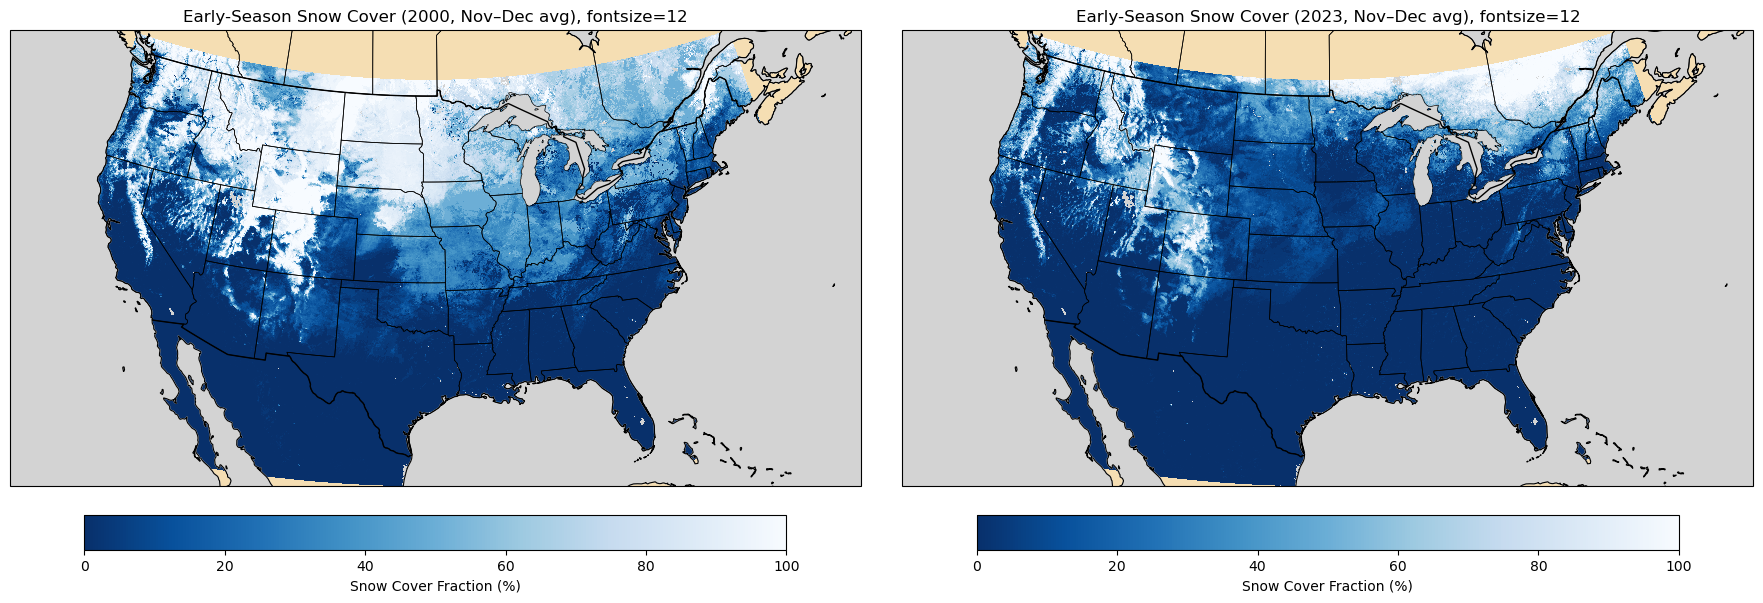

In [6]:
# Select November and December data as early season
idx_2000_nov = np.where((dates.year == 2000) & (dates.month == 11))[0]
idx_2023_nov = np.where((dates.year == 2023) & (dates.month == 11))[0]
idx_2000_dec = np.where((dates.year == 2000) & (dates.month == 12))[0]
idx_2023_dec = np.where((dates.year == 2023) & (dates.month == 12))[0]

# average of November and December
snow_2000_early = np.nanmean(snow_all[np.concatenate([idx_2000_nov, idx_2000_dec])], axis=0)
snow_2023_early = np.nanmean(snow_all[np.concatenate([idx_2023_nov, idx_2023_dec])], axis=0)

SKI_THRESHOLD = 50  # larger than 50% considered as skiable snow cover

cmap_snow = plt.cm.Blues_r
cmap_snow.set_bad(color='lightgray')

fig, axes = plt.subplots(1, 2, figsize=(18, 6),
    subplot_kw={'projection': ccrs.LambertConformal(
        central_longitude=-96, central_latitude=39)})

for ax, data, year in zip(axes, [snow_2000_early, snow_2023_early], [2000, 2023]):
    im = ax.pcolormesh(lons, lats, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap_snow, vmin=0, vmax=100)
    ax.add_feature(cfeature.OCEAN,     color='lightgray', zorder=1)
    ax.add_feature(cfeature.LAND,      color='wheat',     zorder=0)
    ax.add_feature(cfeature.STATES,    linewidth=0.5,     zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8,     zorder=2)
    ax.add_feature(cfeature.BORDERS,   linewidth=1.0,     zorder=2)
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
    ax.set_title(f'Early-Season Snow Cover ({year}, Nov–Dec avg), fontsize=12')
    plt.colorbar(im, ax=ax, label='Snow Cover Fraction (%)',
                 orientation='horizontal', pad=0.05, shrink=0.8)

plt.tight_layout()
plt.savefig('snow_comparison_early_season.png', dpi=150, bbox_inches='tight')
plt.show()

**From November to December 2000, snow cover was widespread across the northern United States, with most regions snow cover fractions exceeding 60%. By 2023, the spatial extent of high snow cover had reduced, particularly across the northern Great Plains and the Midwest. The western mountain ranges retain high snow cover fractions in both years.**

In [ ]:
# Compute annual Nov-Dec mean snow cover across 2000-2023

years = np.arange(2000, 2024)
early_season_annual = np.full((len(years), n_lat, n_lon), np.nan, dtype=np.float32)

for i, yr in enumerate(years):
    mask = (dates.year == yr) & (dates.month.isin([11, 12]))
    if mask.sum() > 0:
        early_season_annual[i] = np.nanmean(snow_all[mask], axis=0)

# Compute slope and p-value of linear trend

from scipy import stats

slope_map = np.full((n_lat, n_lon), np.nan)
pval_map  = np.full((n_lat, n_lon), np.nan)

for i in range(n_lat):
    for j in range(n_lon):
        y     = early_season_annual[:, i, j]
        valid = ~np.isnan(y)
        if valid.sum() >= 10:
            slope, _, _, pval, _ = stats.linregress(years[valid], y[valid])
            slope_map[i, j] = slope
            pval_map[i, j]  = pval

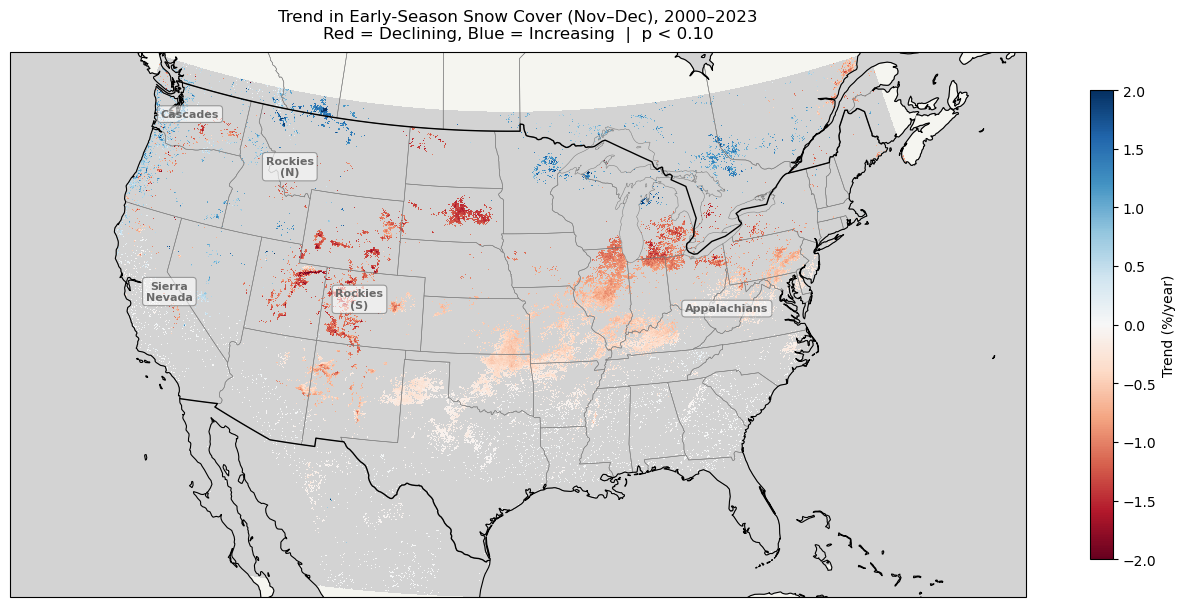

In [45]:
### Early-Season Snow Cover Trend Map
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import cartopy.feature as cfeature

slope_sig = np.where(pval_map < 0.10, slope_map, np.nan)

cmap_trend = plt.cm.RdBu
cmap_trend.set_bad(color='lightgray')

fig, ax = plt.subplots(figsize=(13, 7),
    subplot_kw={'projection': ccrs.LambertConformal(
        central_longitude=-96, central_latitude=39)})

im = ax.pcolormesh(lons, lats, slope_sig,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap_trend, vmin=-2, vmax=2)

ax.add_feature(cfeature.OCEAN,     color='lightgray', zorder=1)
ax.add_feature(cfeature.LAND,      color='#f5f5f0',   zorder=0)
ax.add_feature(cfeature.STATES,    linewidth=0.4,     zorder=2, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8,     zorder=2)
ax.add_feature(cfeature.BORDERS,   linewidth=1.0,     zorder=2)

# label four mountain regions
mountain_labels = {
    'Cascades':        (-121.5, 47.5),
    'Sierra\nNevada':  (-119.5, 38.0),
    'Rockies\n(N)':    (-113.0, 46.0),
    'Rockies\n(S)':    (-106.5, 39.5),
    'Appalachians':    (-81.0,  38.5),
}

for name, (lon, lat) in mountain_labels.items():
    ax.text(lon, lat, name,
            transform=ccrs.PlateCarree(),
            fontsize=8, fontweight='bold',
            color='dimgray', ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.6,
                      edgecolor='dimgray', boxstyle='round,pad=0.3',
                      linewidth=0.8))

ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
ax.set_title(
    'Trend in Early-Season Snow Cover (Nov–Dec), 2000–2023',
    fontsize=12, pad=10)

plt.colorbar(im, ax=ax, label='Trend (%/year)', shrink=0.7)

plt.tight_layout()
plt.savefig('early_season_trend_map.png', dpi=150, bbox_inches='tight')
plt.show()

**The trend map reveals that declining early ski season snow cover is the dominant signal across the continental U.S. Mid- latitude generally experienced significant snow loss. The most severe declines are concentrated in the southern Rockies, where trends reach −2.0%/year. The high latitude regions shows some increasing trend. Gray areas indicate no statistically significant trend.**

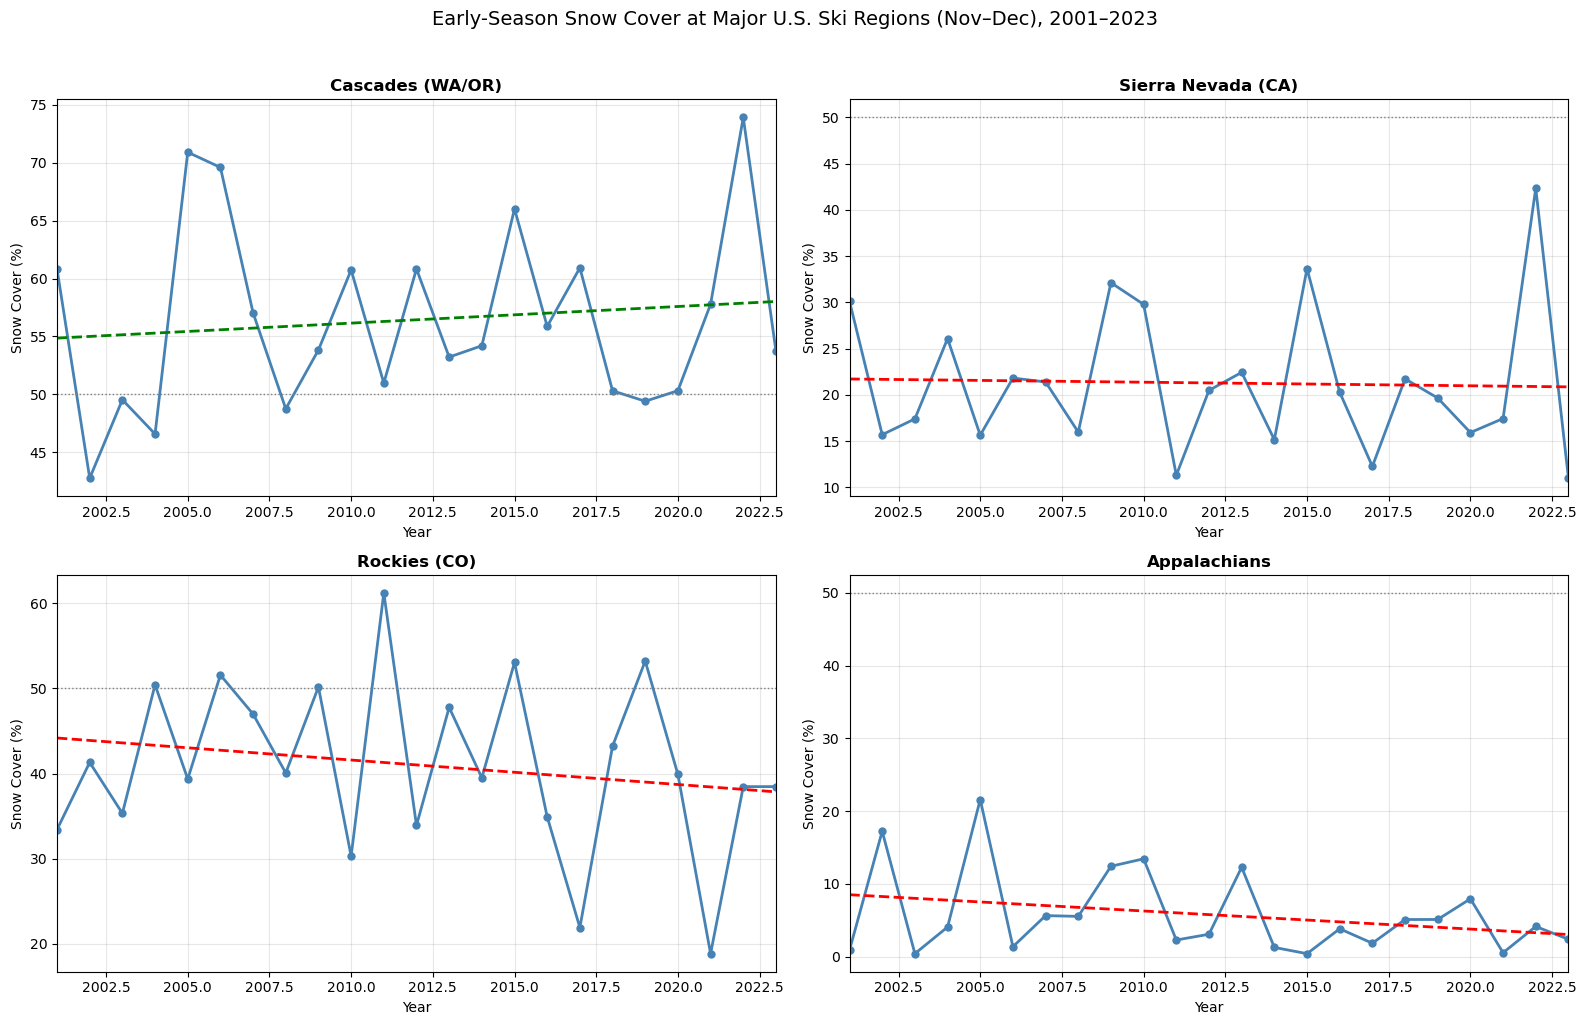

In [46]:
# Early-season snow cover time series by four ski region

years = np.arange(2000, 2024)
years_plot = years[1:]

early_season_annual = np.full((len(years), n_lat, n_lon), np.nan, dtype=np.float32)
for i, yr in enumerate(years):
    mask = (dates.year == yr) & (dates.month.isin([11, 12]))
    if mask.sum() > 0:
        early_season_annual[i] = np.nanmean(snow_all[mask], axis=0)

ski_regions = {
    'Cascades (WA/OR)':   {'lat': (45, 49), 'lon': (-122, -120)},
    'Sierra Nevada (CA)': {'lat': (36, 42), 'lon': (-121, -118)},
    'Rockies (CO)':       {'lat': (37, 41), 'lon': (-107, -104)},
    'Appalachians':       {'lat': (36, 42), 'lon': (-82,  -76)},
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (region_name, bounds) in zip(axes, ski_regions.items()):
    lat_mask = (lats >= bounds['lat'][0]) & (lats <= bounds['lat'][1])
    lon_mask = (lons >= bounds['lon'][0]) & (lons <= bounds['lon'][1])

    ts = np.array([
        np.nanmean(early_season_annual[i][np.ix_(lat_mask, lon_mask)])
        for i in range(1, len(years))
    ])

    ax.plot(years_plot, ts, 'o-', color='steelblue', linewidth=2, markersize=5)

    slope, intercept, _, _, _ = stats.linregress(years_plot, ts)
    ax.plot(years_plot, slope * years_plot + intercept,
            '--', color='red' if slope < 0 else 'green', linewidth=2)

    ax.axhline(y=50, color='gray', linestyle=':', linewidth=1)
    ax.set_title(region_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Snow Cover (%)', fontsize=10)
    ax.set_xlim(2001, 2023)
    ax.grid(True, alpha=0.3)

plt.suptitle('Early-Season Snow Cover at Major U.S. Ski Regions (Nov–Dec), 2001–2023',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ski_early_season_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

**The Cascades show a slight positive trend and consistently maintain snow cover above the 50% threshold. The Sierra Nevada fluctuates largely from year to year, showing no meaningful long-term trend, with coverage remaining well below the 50% threshold on average. The Rockies exhibit some decline, with recent years dropping below 20%. The Appalachians show the lowest absolute snow cover values, consistently below 20% and trending downward.**

### Research Part 2 Potential snowmaking hours in early-season

This section quantifies changes in snowmaking potential across major U.S. ski regions by using hourly wet-bulb temperature and counting the number of hours per early season in which conditions are cold enough for artificial snowmaking, defined as wet-bulb temperature below −2°C.

Wet-bulb temperature $T_w$ is computed from ERA5 2m air temperature $T$ and 2m dewpoint temperature $T_d$:

$$RH = 100 \cdot \frac{\exp\left(\frac{17.625\, T_d}{243.04 + T_d}\right)}{\exp\left(\frac{17.625\, T}{243.04 + T}\right)}$$

$$T_w = T \arctan[0.151977(RH + 8.313659)^{1/2}] + \arctan(T + RH) - \arctan(RH - 1.676331) + 0.00391838 \cdot RH^{3/2} \arctan(0.023101 \cdot RH) - 4.686035$$

In [47]:
import xarray as xr
import numpy as np
import os
import glob

# Compute wet-bulb temperature
era5_dir   = os.path.expanduser('~/Final Project Computing/data/ERA5')
era5_files = sorted(glob.glob(f'{era5_dir}/era5_hourly_*.nc'))

def wet_bulb(T_C, Td_C):
    RH = 100 * np.exp((17.625 * Td_C) / (243.04 + Td_C)) / \
              np.exp((17.625 * T_C)  / (243.04 + T_C))
    RH = np.clip(RH, 0.1, 100)
    Tw = (T_C * np.arctan(0.151977 * (RH + 8.313659)**0.5)
        + np.arctan(T_C + RH)
        - np.arctan(RH - 1.676331)
        + 0.00391838 * RH**1.5 * np.arctan(0.023101 * RH)
        - 4.686035)
    return Tw

# Read grid coordinates from the first file
ds0 = xr.open_dataset(era5_files[0])
era5_lats = ds0.latitude.values
era5_lons = ds0.longitude.values
ds0.close()

years_era5 = list(range(2000, 2026))
n_lat_e    = len(era5_lats)
n_lon_e    = len(era5_lons)

# Compute Tw<-2°C Hours
snowmaking_hours = np.full((len(years_era5), n_lat_e, n_lon_e), np.nan, dtype=np.float32)

for i, (yr, fpath) in enumerate(zip(years_era5, era5_files)):
    ds = xr.open_dataset(fpath)
    T_C  = ds['t2m'].values - 273.15  # K to C
    Td_C = ds['d2m'].values - 273.15
    ds.close()

    Tw = wet_bulb(T_C, Td_C)
    snowmaking_hours[i] = np.sum(Tw < -2, axis=0).astype(np.float32)

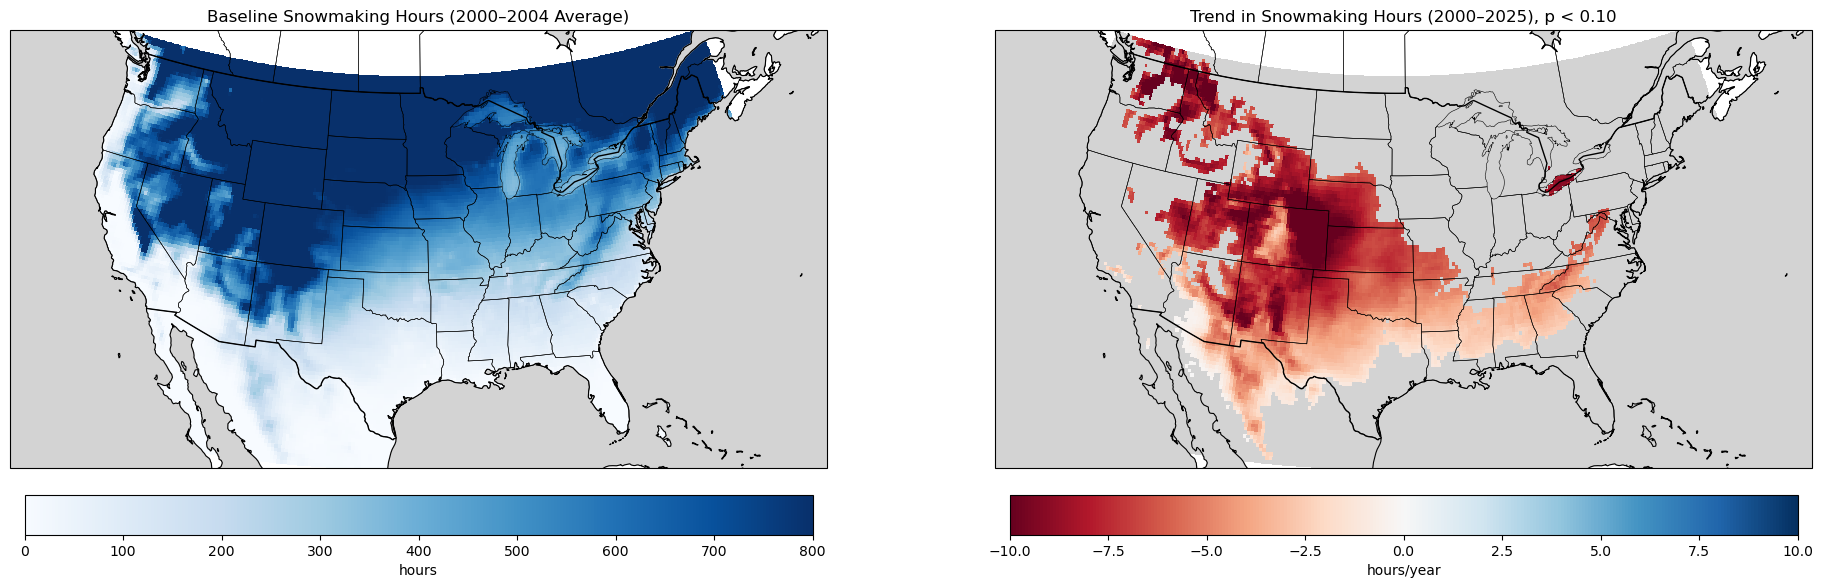

In [48]:
# spatial map trend in snowmaking hours

from scipy import stats

years_era5_arr = np.array(years_era5)
slope_sm = np.full((n_lat_e, n_lon_e), np.nan)
pval_sm  = np.full((n_lat_e, n_lon_e), np.nan)

for i in range(n_lat_e):
    for j in range(n_lon_e):
        y     = snowmaking_hours[:, i, j]
        valid = ~np.isnan(y)
        if valid.sum() >= 10:
            slope_sm[i,j], _, _, pval_sm[i,j], _ = stats.linregress(years_era5_arr[valid], y[valid])

# Only consider significant trends
slope_sig = np.where(pval_sm < 0.10, slope_sm, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(20, 6),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-96, central_latitude=39)})

plots = [
    (axes[0], np.nanmean(snowmaking_hours[:5], axis=0),
     'Blues', 0, 800, 'hours',
     'Baseline Snowmaking Hours (2000–2004 Average)'),
    (axes[1], slope_sig,
     'RdBu', -10, 10, 'hours/year',
     'Trend in Snowmaking Hours (2000–2025), p < 0.10'),
]

for ax, data, cmap, vmin, vmax, clabel, title in plots:
    cmap_use = plt.cm.get_cmap(cmap)
    cmap_use.set_bad(color='lightgray')
    im = ax.pcolormesh(era5_lons, era5_lats, data,
                       transform=ccrs.PlateCarree(),
                       cmap=cmap_use, vmin=vmin, vmax=vmax)
    ax.add_feature(cfeature.OCEAN,     color='lightgray', zorder=1)
    ax.add_feature(cfeature.STATES,    linewidth=0.4,     zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8,     zorder=2)
    ax.add_feature(cfeature.BORDERS,   linewidth=1.0,     zorder=2)
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, label=clabel, orientation='horizontal', pad=0.05, shrink=0.8)

plt.tight_layout()
plt.savefig('snowmaking_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**The baseline map shows that potential snowmaking hours during November to December are highest across the northern U.S. and sorthern Rockies, while the southern states having near-zero viable hours. The trend map shows only statistically significant trend. And all the significant trends show declining snowmaking hours over 2000–2025. The most severe losses are concentrated in the central and southern Rockies and extending into the Northwest region, where trends reach −10 hours/year. It might threaten the operational viability of ski resorts.**

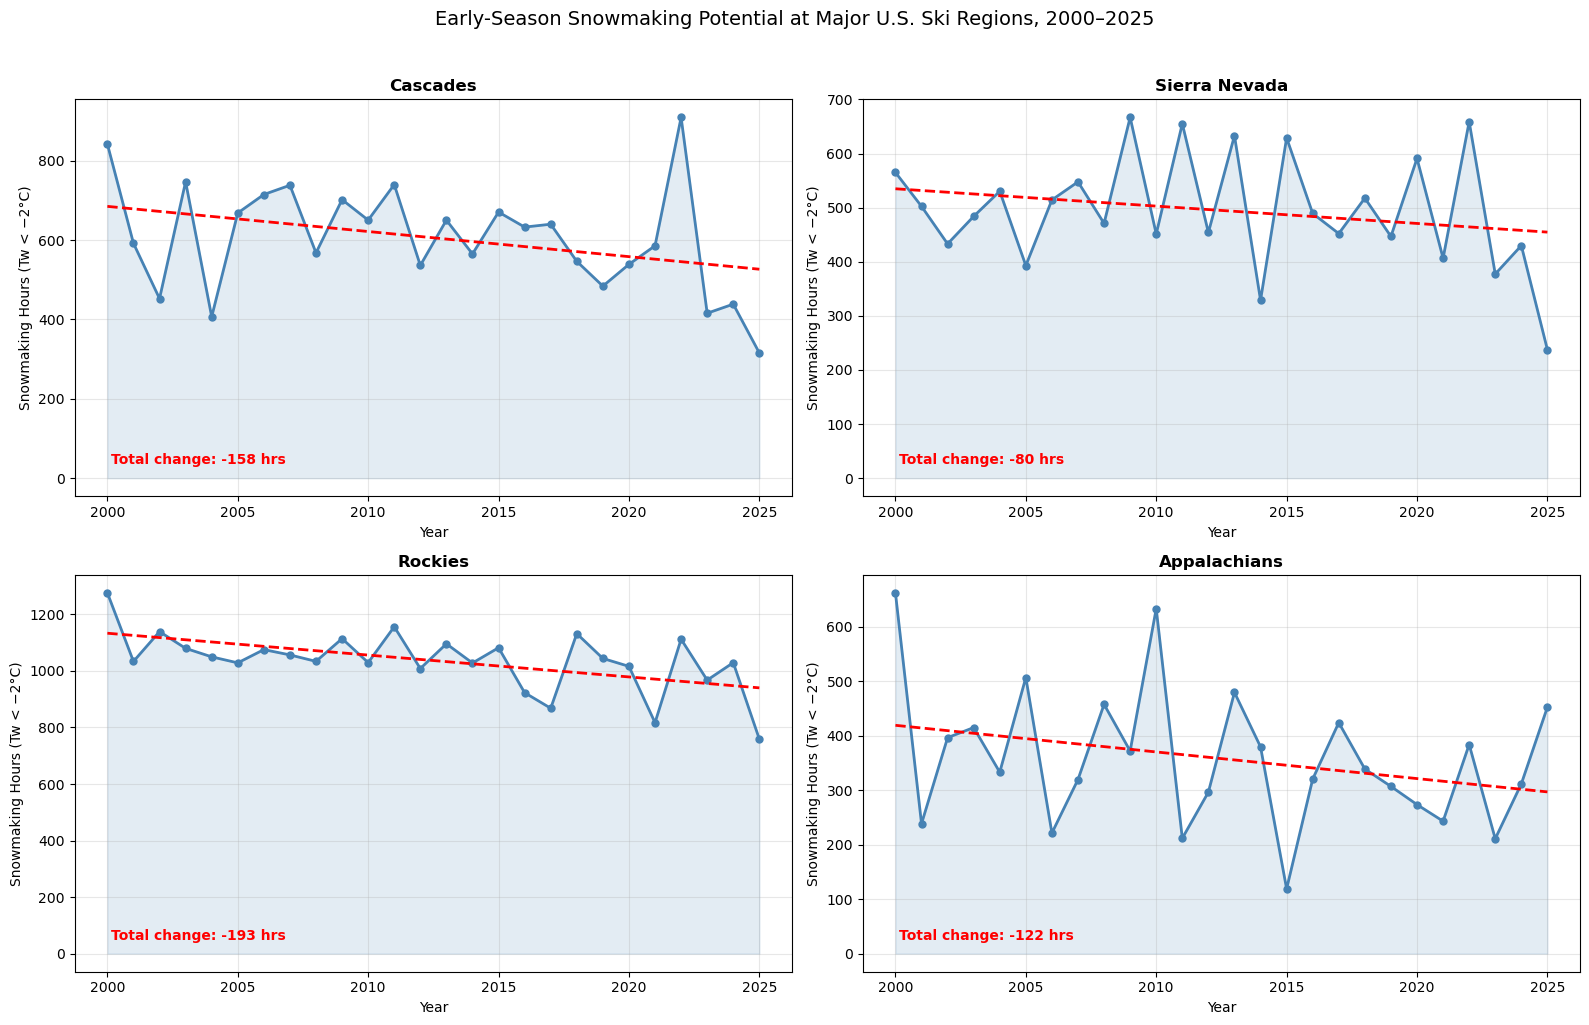

In [49]:
### Snowmaking hours time series by four ski region

years_era5_arr = np.array(years_era5)

ski_regions_era5 = {
    'Cascades':   {'lat': (45, 49), 'lon': (-122, -120)},
    'Sierra Nevada': {'lat': (36, 42), 'lon': (-121, -118)},
    'Rockies':       {'lat': (37, 41), 'lon': (-107, -104)},
    'Appalachians':       {'lat': (36, 42), 'lon': (-82,  -76)},
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (region_name, bounds) in zip(axes.flatten(), ski_regions_era5.items()):
    lat_mask = (era5_lats >= bounds['lat'][0]) & (era5_lats <= bounds['lat'][1])
    lon_mask = (era5_lons >= bounds['lon'][0]) & (era5_lons <= bounds['lon'][1])

    ts = np.array([np.nanmean(snowmaking_hours[i][np.ix_(lat_mask, lon_mask)])
                   for i in range(n_years)])

    # Compute linear trends
    slope, intercept, _, _, _ = stats.linregress(years_era5_arr, ts)
    line_color   = 'red' if slope < 0 else 'green'
    total_change = slope * (years_era5_arr[-1] - years_era5_arr[0])

    ax.plot(years_era5_arr, ts, 'o-', color='steelblue', linewidth=2, markersize=5)
    ax.fill_between(years_era5_arr, ts, alpha=0.15, color='steelblue')
    ax.plot(years_era5_arr, slope * years_era5_arr + intercept,
            '--', color=line_color, linewidth=2)
    # Compute totoal hours change
    ax.annotate(f'Total change: {total_change:+.0f} hrs',
                xy=(0.05, 0.08), xycoords='axes fraction',
                fontsize=10, color=line_color, fontweight='bold')

    ax.set_title(region_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Snowmaking Hours (Tw < −2°C)', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Early-Season Snowmaking Potential at Major U.S. Ski Regions, 2000–2025',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('snowmaking_timeseries_ski.png', dpi=150, bbox_inches='tight')
plt.show()

**All four ski regions show a downward trend in early ski season snowmaking hours. The Rockies record the largest absolute decline, losing 193 hours. The Cascades lose 158 hours in total. The Appalachians show a loss of 122 hours, with lower baseline of around 400 hours, meaning the relative impact is severe. The Sierra Nevada loses 80 hours, suggesting it remains the most resilientin terms of retained snowmaking capacity.**

### Research Part 3: Analysis for difference elevations

This section examines whether early ski season snow cover loss varies among different terrain elevation across the four ski regions. For each MODIS grid cell within the study areas, mean elevation is derived from the Copernicus DEM GLO-30 and used to assign pixels to one of five elevation bands (600–1000 m, 1000–1500 m, 1500–2000 m, 2000–2500 m, and 2500 m+). Snow cover fraction (≥50% threshold) and linear trends are then computed separately for each band following the same methodology as Part 1.

In [51]:
## Build MODIS's resolution elevation grid for each ski region

import rasterio
from rasterio.merge import merge
import numpy as np
import glob

dem_dir = os.path.expanduser('~/Final Project Computing/data/DEM')

region_elev = {} 

for name, bounds in ski_regions.items():
    lat_lo, lat_hi = bounds['lat']
    lon_lo, lon_hi = bounds['lon']

    # Collect all DEM tiles that overlap this region's bounding box
    region_tiles = []
    for lat in range(lat_lo, lat_hi + 1):
        for lon in range(abs(lon_hi), abs(lon_lo) + 1):
            found = glob.glob(f"{dem_dir}/*N{lat:02d}_00_W{lon:03d}_00_DEM.tif")
            region_tiles.extend(found)

    # Transfer tiles into a single array and remove sea region values
    src_files = [rasterio.open(f) for f in region_tiles]
    mosaic, _ = merge(src_files)
    for s in src_files:
        s.close()

    elev_raw = mosaic[0].astype(np.float32)
    elev_raw[elev_raw < -100] = np.nan

    # Coordinate arrays for the full resolution
    n_rows, n_cols = elev_raw.shape
    elev_lats = np.linspace(lat_hi, lat_lo, n_rows)
    elev_lons = np.linspace(lon_lo, lon_hi, n_cols)
    lat_idx = np.where((lats >= lat_lo) & (lats <= lat_hi))[0]
    lon_idx = np.where((lons >= lon_lo) & (lons <= lon_hi))[0]

    # Averaging each 0.05 patch
    elev_2d = np.full((len(lat_idx), len(lon_idx)), np.nan)
    for ii, li in enumerate(lat_idx):
        for jj, lj in enumerate(lon_idx):
            dlat = np.abs(elev_lats - lats[li]) < 0.025
            dlon = np.abs(elev_lons - lons[lj]) < 0.025
            patch = elev_raw[np.ix_(dlat, dlon)]
            elev_2d[ii, jj] = np.nanmean(patch) if patch.size > 0 else np.nan

    region_elev[name] = {'lat_idx': lat_idx, 'lon_idx': lon_idx, 'elev_2d': elev_2d}

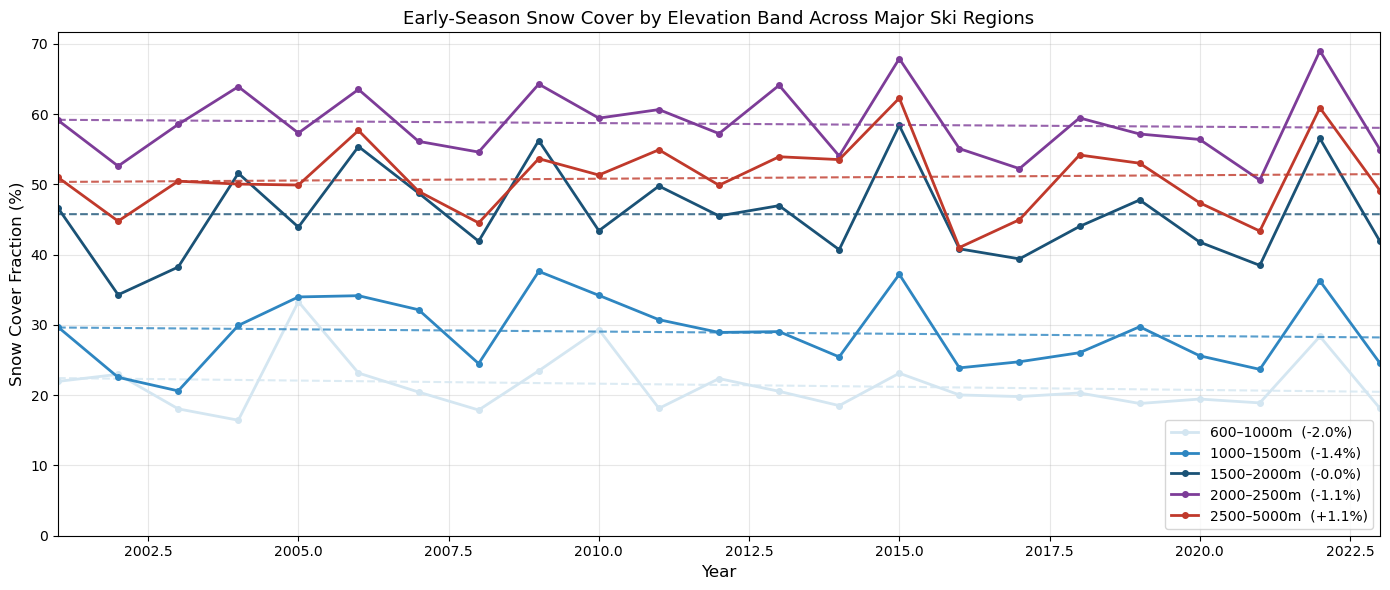

In [53]:
### Snow cover time series by different elevation band
elev_bands = [
    ( 600, 1000, '#d4e6f1'),
    (1000, 1500, '#2e86c1'),
    (1500, 2000, '#1a5276'),
    (2000, 2500, '#7d3c98'),
    (2500, 5000, '#c0392b'),
]

fig, ax = plt.subplots(figsize=(14, 6))

for (e_lo, e_hi, color) in elev_bands:
    # Average snow cover across all regions fall in this elevation band
    ts_all_years = []
    for i in range(1, len(years)): 
        vals = []
        for name, info in region_elev.items():
            li    = info['lat_idx']
            lj    = info['lon_idx']
            emask = (info['elev_2d'] >= e_lo) & (info['elev_2d'] < e_hi)
            if emask.sum() == 0:
                continue
            patch = early_season_annual[i][np.ix_(li, lj)]
            vals.append(np.nanmean(patch[emask]))
        ts_all_years.append(np.nanmean(vals) if vals else np.nan)

    ts    = np.array(ts_all_years)
    valid = ~np.isnan(ts)
    if valid.sum() < 5:
        continue
    slope, intercept, _, _, _ = stats.linregress(years_plot[valid], ts[valid])
    total = slope * (years_plot[-1] - years_plot[0])
    label = f'{e_lo}–{e_hi}m  ({total:+.1f}%)'

    ax.plot(years_plot, ts, 'o-', color=color, linewidth=2, markersize=4, label=label)
    ax.plot(years_plot, slope * years_plot + intercept,
            '--', color=color, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Snow Cover Fraction (%)', fontsize=12)
ax.set_title('Early-Season Snow Cover by Elevation Band Across Major Ski Regions', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(2001, 2023)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('snow_by_elevation_band.png', dpi=150, bbox_inches='tight')
plt.show()

**The figure reveals no strong elevation related pattern in early-season snow cover loss across the study period. All five bands show relatively flat trends. Total changes ranging from −2.0% at the lowest band to +1.1% at the highest band , suggesting that higher elevations may be marginally more resilient, though the value doesn't reach any significant levels.**

### Conclusion

**Early-season snow cover has declined across much of the continental U.S. between 2000 and 2023, with the most significant losses in mid-latitude regions. Potential snowmaking hours have decreased across all four major ski regions over 2000–2025, with the Rockies and Cascades experiencing the largest cumulative losses of 193 and 158 hours respectively, which might threaten skiing resort opening schedules. Contrary to expectation, no clear elevation related pattern in snow loss was detected within the ski regions.**